# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---
**Alumno**: Chelsea Nicole Merryman Gonzalez
**Num de registro**: 4709857
## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
np.random.seed(SEED)

pd.set_option("display.width", 120)
pd.set_option('display.max_columns', None)

In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
import kagglehub
import os

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

archivo = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(archivo)

print("Forma del DataFrame:", df.shape)
print("\nPrimeras filas:")
print(df.head())

c:\Users\chels\Documents\GitHub\IA_practicas\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forma del DataFrame: (5110, 12)

Primeras filas:
      id  gender   age  hypertension  heart_disease ever_married      work_type Residence_type  avg_glucose_level  \
0   9046    Male  67.0             0              1          Yes        Private          Urban             228.69   
1  51676  Female  61.0             0              0          Yes  Self-employed          Rural             202.21   
2  31112    Male  80.0             0              1          Yes        Private          Rural             105.92   
3  60182  Female  49.0             0              0          Yes        Private          Urban             171.23   
4   1665  Female  79.0             1              0          Yes  Self-employed          Rural             174.12   

    bmi   smoking_status  stroke  
0  36.6  formerly smoked       1  
1   NaN     never smoked       1  
2  32.5     never smoked       1  
3  34.4           smokes       1  
4  24.0     never smoked       1  


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
resumen = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "numero_nulos": df.isnull().sum(),
    "porcentaje_nulos": df.isnull().mean() * 100
})

resumen["porcentaje_nulos"] = resumen["porcentaje_nulos"].round(2)

print(resumen)

                  tipo_dato  valores_unicos  numero_nulos  porcentaje_nulos
id                    int64            5110             0              0.00
gender               object               3             0              0.00
age                 float64             104             0              0.00
hypertension          int64               2             0              0.00
heart_disease         int64               2             0              0.00
ever_married         object               2             0              0.00
work_type            object               5             0              0.00
Residence_type       object               2             0              0.00
avg_glucose_level   float64            3979             0              0.00
bmi                 float64             418           201              3.93
smoking_status       object               4             0              0.00
stroke                int64               2             0              0.00


In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.

IDENT     = "id"
NOMINALES = [
    "gender",
    "work_type",
    "smoking_status"]   # sin orden intrinseco
BINARIAS = [
    "ever_married",
    "Residence_type"]   # dos categorias de texto
INDICADOR = [
    "hypertension",
    "heart_disease"]   # ya vienen como 0/1
NUMERICAS = [
    "age",
    "avg_glucose_level",
    "bmi"]
OBJETIVO = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")

Categorias de cada variable de texto:
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:* Las categorias son Other en la variable gender, ya que solo aparece un paciente, y Unknown en smoking_status, ya que representa información desconocida.

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [5]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.

dup_exactos = df.duplicated().sum()

columnas_sin_folio = [c for c in df.columns if c != IDENT]
dup_sin_folio = df.duplicated(subset=columnas_sin_folio).sum()

llave_clinica = NOMINALES + BINARIAS + INDICADOR + ["age"]

mask_repetidos = df.duplicated(
    subset=llave_clinica,
    keep=False
)

filas_repetidas = mask_repetidos.sum()

perfiles_distintos = (
    df.loc[mask_repetidos, llave_clinica]
      .drop_duplicates()
      .shape[0]
)

print(f"(1) Duplicados exactos: {dup_exactos}")
print(f"(2) Duplicados ignorando folio: {dup_sin_folio}")
print(f"(3) Filas involucradas en perfiles clinicos repetidos: {filas_repetidas}")
print(f"    Perfiles clinicos distintos repetidos: {perfiles_distintos}")

(1) Duplicados exactos: 0
(2) Duplicados ignorando folio: 0
(3) Filas involucradas en perfiles clinicos repetidos: 3310
    Perfiles clinicos distintos repetidos: 1019


In [6]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.

llave_clinica = NOMINALES + BINARIAS + INDICADOR + ["age"]
llave_completa = llave_clinica + ["bmi", "avg_glucose_level"]

repetidos = df.duplicated(subset=llave_completa, keep=False)

print("Filas repetidas con bmi y glucosa:", repetidos.sum())
print("Perfiles distintos repetidos:",
      df.loc[repetidos, llave_completa].drop_duplicates().shape[0])

ejemplo = df[df.duplicated(subset=llave_clinica, keep=False)]

for _, grupo in ejemplo.groupby(llave_clinica, dropna=False):
    grupo = grupo.dropna(subset=["bmi", "avg_glucose_level"])
    if len(grupo) >= 2:
        if grupo["bmi"].nunique() > 1 or grupo["avg_glucose_level"].nunique() > 1:
            print("\nEjemplo:")
            print(grupo[["id"] + llave_clinica + ["bmi", "avg_glucose_level"]].head(2))
            break

filas_antes = len(df)

df = df.drop(columns=["id"])

filas_despues = len(df)

print("\nFilas eliminadas:", filas_antes - filas_despues)
print("Columnas eliminadas: id")
print("Forma final:", df.shape)

Filas repetidas con bmi y glucosa: 0
Perfiles distintos repetidos: 0

Ejemplo:
         id  gender work_type smoking_status ever_married Residence_type  hypertension  heart_disease   age   bmi  \
2586  41175  Female  Govt_job        Unknown           No          Urban             0              0  22.0  21.3   
4306  34415  Female  Govt_job        Unknown           No          Urban             0              0  22.0  31.8   

      avg_glucose_level  
2586             123.23  
4306              79.57  

Filas eliminadas: 0
Columnas eliminadas: id
Forma final: (5110, 11)


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:* Se eliminaron 0 filas, ya que bmi y avg_glucose_level en la llave clinica no hay duplicados. Si se hubiera aplicado drop_duplicates(subset=llave_clinica), se habrian eliminado registros de pacientes que comparten las mismas variables categoricas, pero que tienen mediciones diferentes. Se elimino la columna id, porque solo funciona como identificador de cada paciente y no aporta información necesaria para la variable objetivo.


---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [7]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("Nulos por columna:")
print(df.isnull().sum())

print("\nRegistros con smoking_status = 'Unknown':")
print((df["smoking_status"] == "Unknown").sum())

comparacion = df.groupby(df["bmi"].isna()).agg(
    pacientes=("stroke", "size"),
    tasa_stroke=("stroke", "mean"),
    edad_media=("age", "mean")
)

comparacion.index = ["BMI presente", "BMI ausente"]

print("\nComparacion segun disponibilidad de BMI:")
print(comparacion)

Nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Registros con smoking_status = 'Unknown':
1544

Comparacion segun disponibilidad de BMI:
              pacientes  tasa_stroke  edad_media
BMI presente       4909     0.042575   42.865374
BMI ausente         201     0.199005   52.049154


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:* No parece que el bmi falte al azar, porque quienes no lo tienen son mayores y presentan una tasa de ictus mas alta. Una explicacion es que pacientes de mayor edad no pudieron ser medidos. No conviene eliminar esas filas ni imputar solo con la media, estaria mejor usar otras variables clinicas y anadir una nota de BMI faltante.


In [8]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
df["enmascarada"] = (df["smoking_status"] == "Unknown")

print("Proporcion por work_type:")
print(df.groupby("work_type")["enmascarada"].mean())

df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 120],
    labels=["0-18", "18-40", "40-60", "60-120"],
    include_lowest=True
)

print("\nProporcion por grupo de edad:")
print(df.groupby("grupo_edad", observed=False)["enmascarada"].mean())

Proporcion por work_type:
work_type
Govt_job         0.185693
Never_worked     0.363636
Private          0.218803
Self-employed    0.190476
children         0.899563
Name: enmascarada, dtype: float64

Proporcion por grupo de edad:
grupo_edad
0-18      0.774017
18-40     0.216867
40-60     0.194622
60-120    0.186350
Name: enmascarada, dtype: float64


                         n   media  desv_std  asimetria
Observados            4909  28.893     7.854      1.055
Mediana global        5110  28.862     7.700      1.088
Mediana condicionada  5110  28.871     7.720      1.070


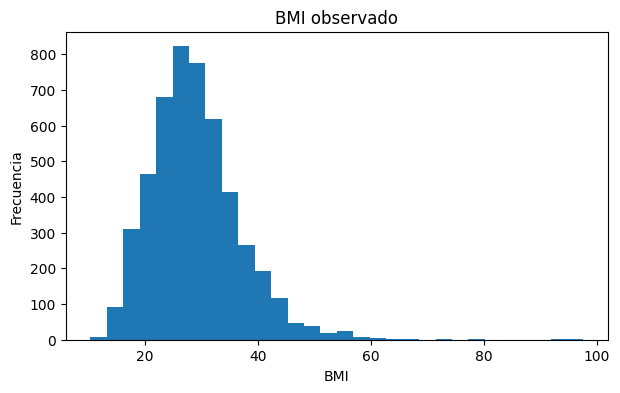

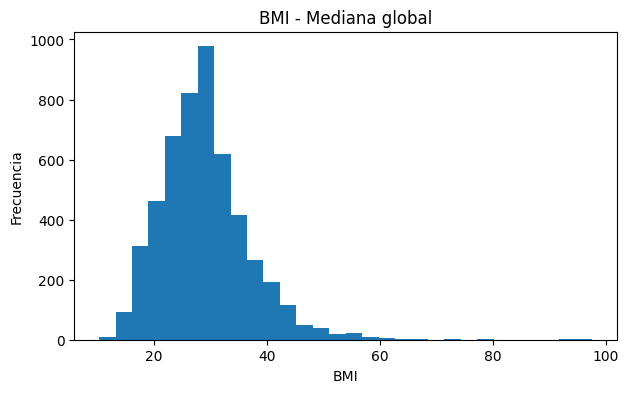

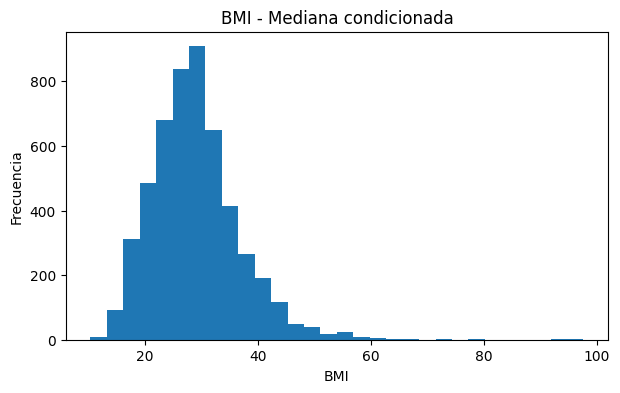


Nulos restantes en bmi: 0


In [9]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
df["bmi_faltante"] = df["bmi"].isna().astype(int)

df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 120],
    labels=["0-18", "18-40", "40-60", "60-120"],
    include_lowest=True
)

bmi_global = df["bmi"].fillna(df["bmi"].median())

mediana_cond = df.groupby(["grupo_edad", "gender"], observed=False)["bmi"].transform("median")
bmi_cond = df["bmi"].fillna(mediana_cond)

bmi_cond = bmi_cond.fillna(df["bmi"].median())

comparacion = pd.DataFrame({
    "n": [
        df["bmi"].count(),
        bmi_global.count(),
        bmi_cond.count()
    ],
    "media": [
        df["bmi"].mean(),
        bmi_global.mean(),
        bmi_cond.mean()
    ],
    "desv_std": [
        df["bmi"].std(),
        bmi_global.std(),
        bmi_cond.std()
    ],
    "asimetria": [
        stats.skew(df["bmi"].dropna()),
        stats.skew(bmi_global),
        stats.skew(bmi_cond)
    ]
}, index=["Observados", "Mediana global", "Mediana condicionada"])

print(comparacion.round(3))

plt.figure(figsize=(7,4))
plt.hist(df["bmi"].dropna(), bins=30)
plt.title("BMI observado")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(bmi_global, bins=30)
plt.title("BMI - Mediana global")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(bmi_cond, bins=30)
plt.title("BMI - Mediana condicionada")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.show()

df["bmi"] = bmi_cond

print("\nNulos restantes en bmi:", df["bmi"].isna().sum())

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:* La desviacion estandar disminuye al imputar, porque varios valores faltantes se sustituyen por valores centrales, reduciendo la variabilidad de los datos.
bmi_faltante conserva la informacion de que pacientes no tenian BMI. Eso se pierde despues de imputar y es util porque la ausencia de BMI no parece aleatoria.

La categoria Unknown de smoking_status se conserva como una categoria aparte, porque son muchos registros y su ausencia esta relacionada con variables como la edad. Imputarla seria poner informacion artificial y eliminar patrones relevantes.


---
## Parte 4 · Valores atípicos (subtema 4.3)


Variable: age
Limite inferior: -29.00
Limite superior: 115.00
Numero de atipicos: 0
Maximo: 82.00


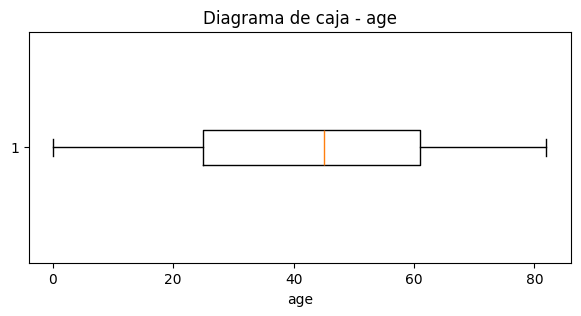


Variable: avg_glucose_level
Limite inferior: 21.98
Limite superior: 169.36
Numero de atipicos: 627
Maximo: 271.74


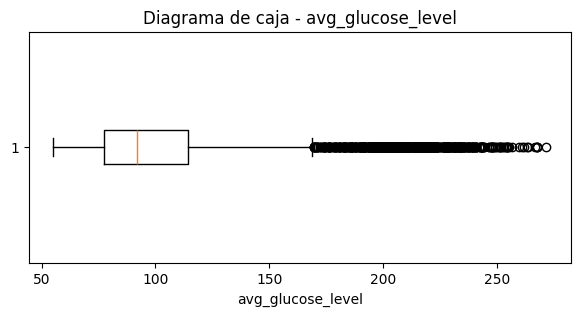


Variable: bmi
Limite inferior: 10.05
Limite superior: 46.45
Numero de atipicos: 123
Maximo: 97.60


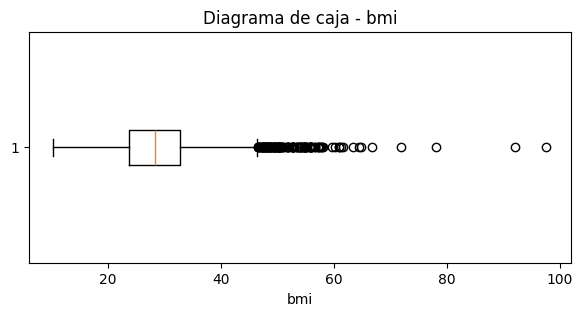

In [10]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

for c in NUMERICAS:
    li, ls = limites_iqr(df[c])

    atipicos = ((df[c] < li) | (df[c] > ls)).sum()

    print(f"\nVariable: {c}")
    print(f"Limite inferior: {li:.2f}")
    print(f"Limite superior: {ls:.2f}")
    print(f"Numero de atipicos: {atipicos}")
    print(f"Maximo: {df[c].max():.2f}")

    plt.figure(figsize=(7, 3))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Diagrama de caja - {c}")
    plt.xlabel(c)
    plt.show()

In [11]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
_, limite_superior = limites_iqr(df["bmi"])

dentro = df[df["bmi"] <= limite_superior]
fuera = df[df["bmi"] > limite_superior]

print(f"Limite superior de BMI: {limite_superior:.2f}")
print(f"Tasa de stroke dentro del limite: {dentro[OBJETIVO].mean():.4f}")
print(f"Tasa de stroke fuera del limite: {fuera[OBJETIVO].mean():.4f}")

print(f"\nRegistros con BMI > 60: {(df['bmi'] > 60).sum()}")
print(f"Maximo BMI observado: {df['bmi'].max():.2f}")

p99 = df["bmi"].quantile(0.99)
bmi_winsor = df["bmi"].clip(upper=p99)

print(f"\nPercentil 99: {p99:.2f}")
print(f"Asimetria antes: {stats.skew(df['bmi']):.4f}")
print(f"Asimetria despues de winsorizar: {stats.skew(bmi_winsor):.4f}")

Limite superior de BMI: 46.45
Tasa de stroke dentro del limite: 0.0493
Tasa de stroke fuera del limite: 0.0244

Registros con BMI > 60: 13
Maximo BMI observado: 97.60

Percentil 99: 52.89
Asimetria antes: 1.0699
Asimetria despues de winsorizar: 0.6736


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:* Yo conservaria los atipicos de bmi, porque siguen siendo valores posibles y no creo que sean errores. Los ceros de colesterol de la Practica 7 eran valores imposibles, por lo que eran datos faltantes.
Para la Parte 8, los valores extremos de bmi estaran presentes y pueden influir en modelos sensibles a valores grandes o en el escalado.


---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [12]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
# [12] Variables derivadas con criterio clinico

df["imc_cat"] = pd.cut(
    df["bmi"],
    bins=[-np.inf, 18.5, 25, 30, np.inf],
    labels=["Bajo peso", "Normal", "Sobrepeso", "Obesidad"],
    right=False)

df["glucosa_cat"] = pd.cut(
    df["avg_glucose_level"],
    bins=[-np.inf, 140, 200, np.inf],
    labels=["<140", "140-199", ">=200"],
    right=False)

df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]

df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 120],
    labels=["0-18", "18-40", "40-60", "60-120"],
    include_lowest=True)

for c in ["imc_cat", "glucosa_cat", "n_comorbilidades", "grupo_edad"]:
    print(f"\n{c}")
    print(
        df.groupby(c, observed=False)[OBJETIVO]
          .agg(conteo="count", tasa_stroke="mean")
          .round(4))


imc_cat
           conteo  tasa_stroke
imc_cat                       
Bajo peso     337       0.0030
Normal       1264       0.0285
Sobrepeso    1558       0.0700
Obesidad     1951       0.0528

glucosa_cat
             conteo  tasa_stroke
glucosa_cat                     
<140           4289       0.0364
140-199         387       0.0956
>=200           434       0.1290

n_comorbilidades
                  conteo  tasa_stroke
n_comorbilidades                     
0                   4400       0.0339
1                    646       0.1347
2                     64       0.2031

grupo_edad
            conteo  tasa_stroke
grupo_edad                     
0-18           916       0.0022
18-40         1328       0.0045
40-60         1562       0.0410
60-120        1304       0.1357


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:* Los cortes de imc_cat siguen la clasificacion del IMC: <18.5 bajo peso, 18.5-24.9 normal, 25-29.9 sobrepeso y >30 obesidad. En glucosa_cat, 140 y 200 mg/dL se usan como referencias de glucosa y diabetes, aunque solo son orientativas. grupo_edad usa cortes por etapa de vida, mientras que n_comorbilidades suma hipertension y cardiopatia.

Las variables glucosa_cat, n_comorbilidades y grupo_edad muestran una tasa de stroke creciente, imc_cat no es monotona. Además son discretizaciones de variables que ya existen como bmi, avg_glucose_level y age.


---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [13]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

categoricas = NOMINALES + BINARIAS + ["imc_cat", "glucosa_cat", "grupo_edad"]

for opcion in [None, "first", "if_binary"]:
    encoder = OneHotEncoder(drop=opcion, sparse_output=False, handle_unknown="ignore")
    X_temp = encoder.fit_transform(df[categoricas])
    print(f"drop={opcion}: {X_temp.shape[1]} columnas")

encoder = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
X_cod = encoder.fit_transform(df[categoricas])

nombres = encoder.get_feature_names_out(categoricas)
X_cod = pd.DataFrame(X_cod, columns=nombres, index=df.index)

print("\nForma de la matriz codificada:", X_cod.shape)

frecuencias = X_cod.sum()
col_menor = frecuencias.idxmin()

print("Columna con menor frecuencia:", col_menor)
print("Registros que la activan:", int(frecuencias.min()))

drop=None: 27 columnas
drop=first: 19 columnas
drop=if_binary: 25 columnas

Forma de la matriz codificada: (5110, 25)
Columna con menor frecuencia: gender_Other
Registros que la activan: 1


In [14]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(df[["work_type"]])

nuevo = pd.DataFrame({"work_type": ["Pensionado"]})

resultado = encoder.transform(nuevo)

print("Categorias conocidas:", encoder.categories_[0])
print("Resultado para 'Pensionado':", resultado)

Categorias conocidas: ['Govt_job' 'Never_worked' 'Private' 'Self-employed' 'children']
Resultado para 'Pensionado': [[0. 0. 0. 0. 0.]]


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:* Con drop='first', una variable de cinco categorias pasa de 5 a 4 columnas, mientras que en binaria pasa de 2 a 1. Se elimina una categoria de referencia, pero en binaria una sola columna basta para toda la variable, en la otra se necesitan cuatro indicadores.
La columna de frecuencia minima no la eliminaria a ojo. La conservaria y dejaria que en la Parte 9 una regla explicita decida si debe descartarse.


---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [15]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
from sklearn.preprocessing import PowerTransformer

resultados = []

for c in NUMERICAS:
    x = df[c].dropna()

    # Transformaciones
    sqrt_x = np.sqrt(x)
    log_x = np.log1p(x)

    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    yj_x = pt.fit_transform(x.to_numpy().reshape(-1, 1)).ravel()

    resultados.append({
        "variable": c,
        "asimetria_original": stats.skew(x),
        "asimetria_sqrt": stats.skew(sqrt_x),
        "asimetria_log1p": stats.skew(log_x),
        "asimetria_yeo_johnson": stats.skew(yj_x),
        "lambda_yj": pt.lambdas_[0]
    })

tabla_transformaciones = pd.DataFrame(resultados)

print(tabla_transformaciones.round(4))

            variable  asimetria_original  asimetria_sqrt  asimetria_log1p  asimetria_yeo_johnson  lambda_yj
0                age             -0.1370         -0.7860          -1.6769                -0.2787     0.8602
1  avg_glucose_level              1.5718          1.2424           0.8892                 0.0845    -1.0759
2                bmi              1.0699          0.4750           0.0212                -0.0007    -0.0249


Asimetria original: 1.5718
Asimetria log1p: 0.8892
Asimetria Yeo-Johnson: 0.0845


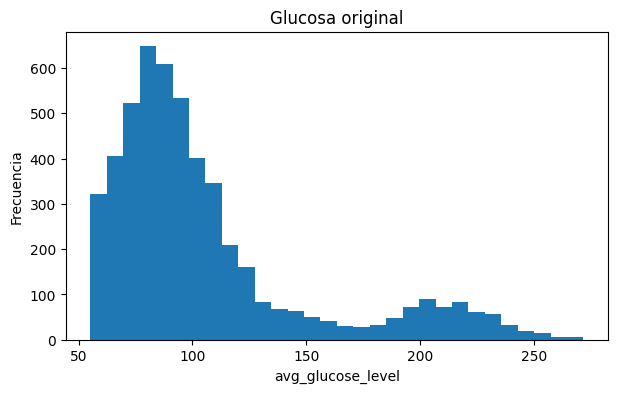

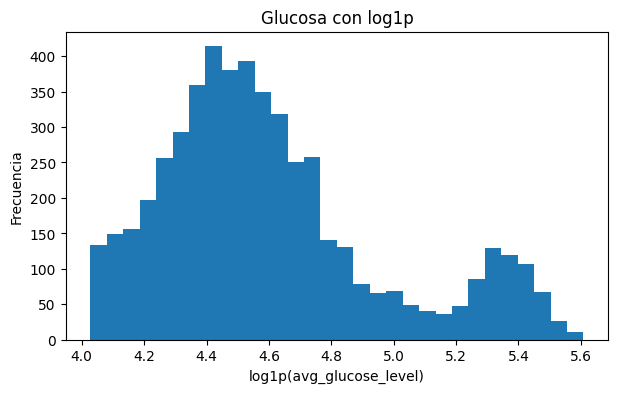

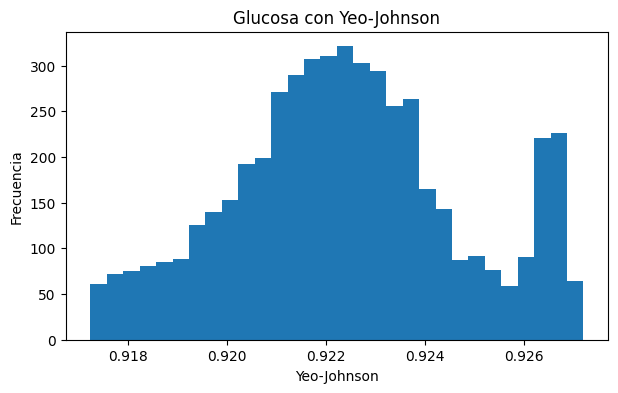


Porcentaje por categoria clinica:
glucosa_cat
<140       83.93
140-199     7.57
>=200       8.49
Name: proportion, dtype: float64


In [16]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
from sklearn.preprocessing import PowerTransformer

x = df["avg_glucose_level"]

x_log = np.log1p(x)

pt = PowerTransformer(method="yeo-johnson", standardize=False)
x_yj = pt.fit_transform(x.to_numpy().reshape(-1, 1)).ravel()

print("Asimetria original:", round(stats.skew(x), 4))
print("Asimetria log1p:", round(stats.skew(x_log), 4))
print("Asimetria Yeo-Johnson:", round(stats.skew(x_yj), 4))

plt.figure(figsize=(7,4))
plt.hist(x, bins=30)
plt.title("Glucosa original")
plt.xlabel("avg_glucose_level")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(x_log, bins=30)
plt.title("Glucosa con log1p")
plt.xlabel("log1p(avg_glucose_level)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(x_yj, bins=30)
plt.title("Glucosa con Yeo-Johnson")
plt.xlabel("Yeo-Johnson")
plt.ylabel("Frecuencia")
plt.show()

porcentajes = df["glucosa_cat"].value_counts(normalize=True, sort=False) * 100

print("\nPorcentaje por categoria clinica:")
print(porcentajes.round(2))

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:* age: no la transformaria. Ya tiene una asimetria y el logaritmo la empeora, porque comprime más las edades altas y genera una asimetría negativa mayor.
bmi: sí la transformaría, con log1p o Yeo Johnson.
avg_glucose_level: no intentaría arreglarla solo con una potencia. Aunque se pueda reducir la asimetria, su distribucion es una estructura bimodal. Una transformación de potencia no elimina esa mezcla de poblaciones. Como solucion, esta glucosa_cat con los cortes clínicos de 140 y 200 mg/dL.


---
## Parte 8 · Escalamiento (subtema 4.6)

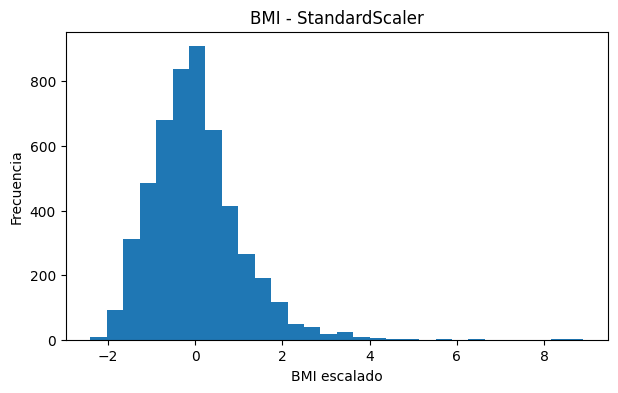

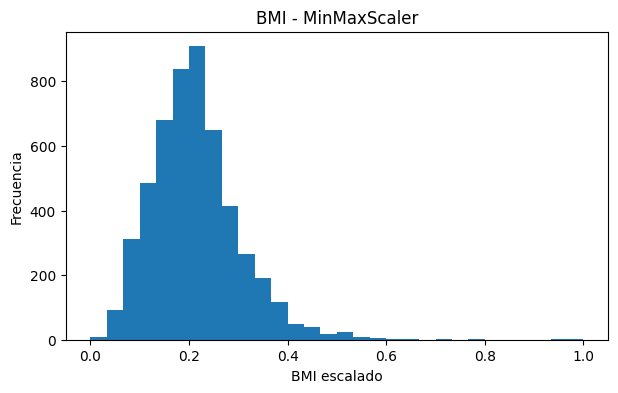

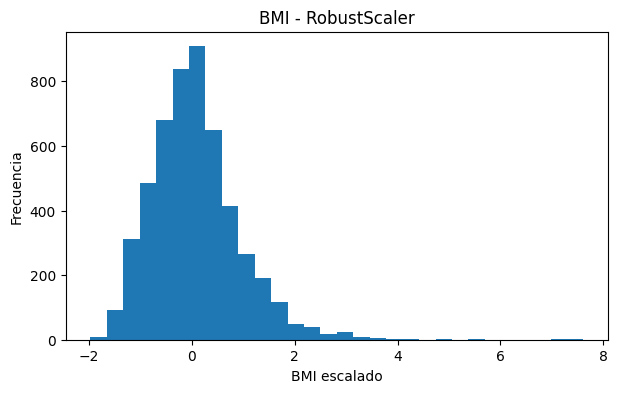

        escalador  minimo  maximo  amplitud_90  asimetria
0  StandardScaler -2.4056  8.9031       3.2326     1.0699
1    MinMaxScaler  0.0000  1.0000       0.2859     1.0699
2    RobustScaler -1.9780  7.6154       2.7423     1.0699


In [17]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

x = df[["bmi"]]

escaladores = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

resultados = []

for nombre, scaler in escaladores.items():
    x_scaled = scaler.fit_transform(x).ravel()

    resultados.append({
        "escalador": nombre,
        "minimo": x_scaled.min(),
        "maximo": x_scaled.max(),
        "amplitud_90": np.percentile(x_scaled, 95) - np.percentile(x_scaled, 5),
        "asimetria": stats.skew(x_scaled)
    })

    plt.figure(figsize=(7,4))
    plt.hist(x_scaled, bins=30)
    plt.title(f"BMI - {nombre}")
    plt.xlabel("BMI escalado")
    plt.ylabel("Frecuencia")
    plt.show()

tabla_escaladores = pd.DataFrame(resultados)

print(tabla_escaladores.round(4))

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:* La asimetria es igual en los tres escaladores porque solo cambian la escala de los datos.
Elegiria RobustScaler porque es menos sensible a los atipicos, que decidimos conservar. No escalaria variables binarias ni categoricas codificadas en 0/1, porque ya están en una escala adecuada para el modelo.


---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [18]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
columnas_base = NUMERICAS + INDICADOR + ["bmi_faltante", "n_comorbilidades"]

X = pd.concat([
    df[columnas_base],
    X_cod
], axis=1)

y = df[OBJETIVO].copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nColumnas de X:")
print(X.columns.tolist())

Forma de X: (5110, 32)
Forma de y: (5110,)

Columnas de X:
['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'bmi_faltante', 'n_comorbilidades', 'gender_Female', 'gender_Male', 'gender_Other', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'ever_married_Yes', 'Residence_type_Urban', 'imc_cat_Bajo peso', 'imc_cat_Normal', 'imc_cat_Obesidad', 'imc_cat_Sobrepeso', 'glucosa_cat_140-199', 'glucosa_cat_<140', 'glucosa_cat_>=200', 'grupo_edad_0-18', 'grupo_edad_18-40', 'grupo_edad_40-60', 'grupo_edad_60-120']


In [19]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

descartadas = X.columns[~selector.get_support()]

print("Columnas descartadas:")
print(descartadas.tolist())

varianzas = X.var().sort_values()

print("\nCinco varianzas mas bajas:")
print(varianzas.head(5))

Columnas descartadas:
['gender_Other', 'work_type_Never_worked']

Cinco varianzas mas bajas:
gender_Other              0.000196
work_type_Never_worked    0.004288
bmi_faltante              0.037795
heart_disease             0.051104
imc_cat_Bajo peso         0.061612
dtype: float64


In [20]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=SEED)

pearson = X.corrwith(y)

relevancia = pd.DataFrame({
    "mutual_info": mi,
    "pearson": pearson.values
}, index=X.columns)

relevancia = relevancia.sort_values("mutual_info", ascending=False)

print(relevancia.round(4))

                                mutual_info  pearson
age                                  0.0369   0.2453
grupo_edad_60-120                    0.0275   0.2366
n_comorbilidades                     0.0176   0.1746
grupo_edad_18-40                     0.0099  -0.1217
glucosa_cat_>=200                    0.0083   0.1136
bmi                                  0.0079   0.0405
work_type_children                   0.0077  -0.0839
ever_married_Yes                     0.0077   0.1083
avg_glucose_level                    0.0053   0.1319
grupo_edad_0-18                      0.0052  -0.1010
glucosa_cat_<140                     0.0042  -0.1312
grupo_edad_40-60                     0.0039  -0.0239
heart_disease                        0.0035   0.1349
work_type_Never_worked               0.0034  -0.0149
imc_cat_Obesidad                     0.0028   0.0148
hypertension                         0.0027   0.1279
imc_cat_Sobrepeso                    0.0024   0.0653
gender_Male                          0.0023   

In [21]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
cols_age = [c for c in X.columns if c.startswith("grupo_edad_")]

print("Correlacion de age con columnas one-hot de grupo_edad:")
print(X[cols_age].corrwith(X["age"]).round(4))

pares = {
    "age": "grupo_edad_",
    "bmi": "imc_cat_",
    "avg_glucose_level": "glucosa_cat_"
}

for continua, prefijo in pares.items():
    cols = [c for c in X.columns if c.startswith(prefijo)]
    print(f"\nCorrelacion de {continua} con su version discretizada:")
    print(X[cols].corrwith(X[continua]).round(4))

es_combinacion = np.allclose(
    X["n_comorbilidades"],
    X["hypertension"] + X["heart_disease"]
)

print("\n¿n_comorbilidades = hypertension + heart_disease?:", es_combinacion)

if es_combinacion:
    X = X.drop(columns=["n_comorbilidades"])
    print("Se elimino n_comorbilidades por ser una combinacion lineal exacta.")

Correlacion de age con columnas one-hot de grupo_edad:
grupo_edad_0-18     -0.7037
grupo_edad_18-40    -0.3432
grupo_edad_40-60     0.2198
grupo_edad_60-120    0.7321
dtype: float64

Correlacion de age con su version discretizada:
grupo_edad_0-18     -0.7037
grupo_edad_18-40    -0.3432
grupo_edad_40-60     0.2198
grupo_edad_60-120    0.7321
dtype: float64

Correlacion de bmi con su version discretizada:
imc_cat_Bajo peso   -0.4214
imc_cat_Normal      -0.5015
imc_cat_Obesidad     0.7634
imc_cat_Sobrepeso   -0.1085
dtype: float64

Correlacion de avg_glucose_level con su version discretizada:
glucosa_cat_140-199    0.4032
glucosa_cat_<140      -0.8812
glucosa_cat_>=200      0.7781
dtype: float64

¿n_comorbilidades = hypertension + heart_disease?: True
Se elimino n_comorbilidades por ser una combinacion lineal exacta.


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:* Los tres criterios evaluan aspectos diferentes. La varianza permite detectar columnas que casi no cambian, Pearson mide relaciones lineales con stroke, mientras que la información mutua puede detectar relaciones no lineales. Por eso variables como bmi_faltante pueden ocupar posiciones distintas segun el criterio usado.
grupo_edad esta relacionada con age, y n_comorbilidades es la suma de hypertension y heart_disease. Conservaria glucosa_cat, ya que aporta una representacion adicional, pero eliminaria grupo_edad, n_comorbilidades e imc_cat por redundancia o poca informacion.


In [22]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
from sklearn.preprocessing import RobustScaler

eliminar = list(descartadas)
eliminar += [c for c in X.columns if c.startswith("grupo_edad_")]
eliminar += [c for c in X.columns if c.startswith("imc_cat_")]

if "n_comorbilidades" in X.columns:
    eliminar.append("n_comorbilidades")

eliminar = list(set(eliminar))
X_final = X.drop(columns=eliminar, errors="ignore").copy()

continuas = ["age", "avg_glucose_level", "bmi"]

scaler = RobustScaler()
X_final[continuas] = scaler.fit_transform(X_final[continuas])

print("Forma final:", X_final.shape)
print("\nColumnas finales:")
print(X_final.columns.tolist())

print("\nPrimeras filas:")
print(X_final.head())

Forma final: (5110, 21)

Columnas finales:
['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'bmi_faltante', 'gender_Female', 'gender_Male', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'ever_married_Yes', 'Residence_type_Urban', 'glucosa_cat_140-199', 'glucosa_cat_<140', 'glucosa_cat_>=200']

Primeras filas:
        age  avg_glucose_level       bmi  hypertension  heart_disease  bmi_faltante  gender_Female  gender_Male  \
0  0.611111           3.712987  0.912088             0              1             0            0.0          1.0   
1  0.444444           2.994300  0.087912             0              0             1            1.0          0.0   
2  0.972222           0.380920  0.461538             0              1             0            0.0          1.0   
3  0.111111           2.153481  0.670330       

---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` |0|N/A|ninguna|ninguna|no|no|
| `gender` |0|N/A|one hot|ninguna|no|si, pero other se descarta|
| `age` |0|se conserva|numerica|ninguna|RobustScaler|si|
| `hypertension` |0|N/A|0/1|ninguna|no|si|
| `heart_disease` |0|N/A|0/1|ninguna|no|si|
| `ever_married` |0|N/A|one hot|ninguna|no|si|
| `work_type` |0|N/A|one hot|ninguna|no|si|
| `Residence_type` |0|N/A|one hot|ninguna|no|si|
| `avg_glucose_level` |0|se conserva|numerica|ninguna|RobustScaler|si|
| `bmi` |201|se conserva|numerica|yeo johnson|RobustScaler|si|
| `smoking_status` |1544 unknown|N/A|one hot|ninguna|no|si|

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.

*Sus respuestas:*
1. Dos filas con el mismo perfil solo podrian considerarse del mismo paciente si compartieran un identificador persistente del paciente. Coincidir en edad, sexo, hipertension, cardiopatia, estado civil, tipo de trabajo, residencia y tabaquismo no es suficiente.
Esto se vio en el analisis: 3310 filas compartian perfil y correspondian a 1019 perfiles repetidos, pero al agregar bmi y avg_glucose_level quedaron 0 duplicados exactos. Por ello, eran pacientes diferentes con características similares.

2. Los pacientes con bmi registrado tuvieron una tasa de stroke de 4.26%, mientras que en quienes no tenian BMI fue de 19.90%. La edad media paso de 42.87 a 52.05. La ausencia del BMI no es completamente aleatoria.
Los pacientes mayores no pudieron ser pesados o medidos. La imputacion reemplaza el valor faltante, pero borra la informacion de que originalmente estaba ausente. Por eso se creo bmi_faltante.

3. En smoking_status, 1544 registros aparecen como Unknown. Aunque representa informacion faltante, se decidio conservarla como categoria porque es muy frecuente y esta relacionada con otras caracteristicas.
En la Practica 7, un colesterol igual a cero era distinto porque representa un valor imposible y podia identificarse como un dato faltante mal codificado. Unknown no inventa un valor falso, indica que la informacion no se conoce.

4. La variable del problema fue avg_glucose_level. Aunque el logaritmo y Yeo Johnson pueden reducir su asimetria, no consiguen convertirla en una distribucion simetrica.
La razon es que la distribucion presenta una estructura compatible con mas de un grupo o moda. Las transformaciones de potencia pueden corregir asimetrias, pero no eliminan una mezcla de subpoblaciones.

5. Si el modelo se desplegara en un hospital donde el 40 % de los expedientes carece de BMI, reconsideraria la imputacion. Una mediana podria seguir siendo util, pero seria necesario evaluar si sigue representando a la poblacion.
Lo que mantendria seria bmi_faltante. Con 40% de ausencia seria mas importante, porque permite distinguir entre un BMI realmente observado y uno reconstruido mediante imputacion. Mantendria la decision de no eliminar esas filas.

6. Una discretizacion es util cuando aporta una representacion adicional que facilita capturar una relacion relevante con el objetivo. Es redundante cuando simplemente repite casi la misma informacion que ya contiene la variable continua, sin aportar una señal nueva suficiente.
Por eso se decidio conservar glucosa_cat, ya que permite representar los distintos rangos de glucosa y complementa una distribucion que no se soluciono bien con transformaciones.Se elimino grupo_edad porque repetia gran parte de la informacion de age, e imc_cat porque aportaba poco respecto a bmi. Tambien se elimino n_comorbilidades, ya que añadia redundancia.